In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from pathlib import Path
import pandas as pd

# 1) جست‌وجوی فایل در کل MyDrive
candidates = list(Path('/content/drive/MyDrive').rglob('AT_data.csv'))
print('Found:', [str(p) for p in candidates])

if not candidates:
    raise FileNotFoundError('هیچ AT_data.csv در MyDrive پیدا نشد. نام/پسوند/محل را چک کن.')

file_path = str(candidates[0])
print('Using:', file_path)

# 2) تلاش برای خواندن با چند انکودینگ رایج
encodings = [None, 'utf-8', 'utf-8-sig', 'cp1252', 'latin1']
last_err = None
for enc in encodings:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print('Loaded with encoding:', enc)
        break
    except UnicodeDecodeError as e:
        last_err = e
else:
    raise last_err

df.head()


Found: ['/content/drive/MyDrive/Colab Notebooks/AT_data.csv', '/content/drive/MyDrive/code1-seq-to-seq/Novel-Seq2Seq-Module-master/prepare_data/data/AT_data.csv', '/content/drive/MyDrive/Edit-Novel-Seq2Seq-Module-master/prepare_data/data/AT_data.csv']
Using: /content/drive/MyDrive/Colab Notebooks/AT_data.csv
Loaded with encoding: None


,time,load,temperature,windspeed
0,2008-01-01 00:00:00,6080.0,-5.437,2.71
1,2008-01-01 01:00:00,5822.0,-5.631,2.72
2,2008-01-01 02:00:00,5436.0,-5.799,2.69
3,2008-01-01 03:00:00,5253.0,-5.931,2.67
4,2008-01-01 04:00:00,5260.0,-6.110,2.61


In [4]:
# ------------------------
# 1) بارگذاری داده
# ------------------------

file_path = '/content/drive/MyDrive/Edit-Novel-Seq2Seq-Module-master/prepare_data/data/AT_data.csv'
df = pd.read_csv(file_path)
df.head()

,time,load,temperature,windspeed
0,2008-01-01 00:00:00,6080.0,-5.437,2.71
1,2008-01-01 01:00:00,5822.0,-5.631,2.72
2,2008-01-01 02:00:00,5436.0,-5.799,2.69
3,2008-01-01 03:00:00,5253.0,-5.931,2.67
4,2008-01-01 04:00:00,5260.0,-6.110,2.61


In [18]:
# تبدیل زمان به datetime
df["time"] = pd.to_datetime(df["time"])

In [19]:
# ------------------------
# 2) ساخت فیچرهای تقویمی
# ------------------------

# ساعت روز
df["hour_int"] = df["time"].dt.hour
df["sin_hour"] = np.sin(2 * np.pi * df["hour_int"] / 24.0)
df["cos_hour"] = np.cos(2 * np.pi * df["hour_int"] / 24.0)

# روز هفته (0=Mon,...,6=Sun)
df["dow_int"]  = df["time"].dt.dayofweek
df["sin_dow"]  = np.sin(2 * np.pi * df["dow_int"] / 7.0)
df["cos_dow"]  = np.cos(2 * np.pi * df["dow_int"] / 7.0)

# ماه سال
df["month_int"] = df["time"].dt.month
df["sin_month"] = np.sin(2 * np.pi * df["month_int"] / 12.0)
df["cos_month"] = np.cos(2 * np.pi * df["month_int"] / 12.0)

# آخر هفته
df["is_weekend"] = (df["dow_int"] >= 5).astype(int)

In [20]:

# ------------------------
# 3) LAG ساخت (کاملاً causal)
# ------------------------
# Lags: 1h, 24h, 168h

for L in (1, 24, 168):
    df[f"load_lag{L}"] = df["load"].shift(L)

In [21]:
# Rolling windows: 24h و 168h (mean/std) — شیفت می‌کنیم تا t-1 باشد و نشت اطلاعات نداشته باشیم
for W in (24, 168):
    df[f"load_ma{W}"]  = df["load"].rolling(W).mean().shift(1)
    df[f"load_std{W}"] = df["load"].rolling(W).std().shift(1)

In [22]:
# حذف ردیف‌های ناقص ناشی از lag/rolling
df_clean = df.dropna().reset_index(drop=True)
before = len(df)
after = len(df_clean)
removed = before - after
print(f"📊 تعداد ردیف‌ها قبل از حذف: {before}")
print(f"📉 تعداد ردیف‌ها بعد از حذف: {after}")
print(f"❌ تعداد ردیف‌های حذف‌شده: {removed}")

📊 تعداد ردیف‌ها قبل از حذف: 78912
📉 تعداد ردیف‌ها بعد از حذف: 78744
❌ تعداد ردیف‌های حذف‌شده: 168


In [23]:
!pip install xlsxwriter


In [24]:
# ------------------------
# 4) ماتریس همبستگی
# ------------------------
#numdf = df_clean.select_dtypes(include=[np.number])
drop_cols = ["hour_int", "dow_int", "month_int"]
numdf = df_clean.drop(columns=drop_cols).select_dtypes(include=[np.number])
#corr = numdf.corr()

corr = numdf.corr(method="pearson")

In [12]:
# ذخیره اکسل با دو شیت: features + correlation
out_xlsx = "AT_features_with_corr.xlsx"
with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
    df_clean.to_excel(writer, sheet_name="features", index=False)
    corr.to_excel(writer, sheet_name="correlation")

print("✅ فایل اکسل ساخته شد:", out_xlsx)
print("شکل نهایی داده:", df_clean.shape)

✅ فایل اکسل ساخته شد: AT_features_with_corr.xlsx
شکل نهایی داده: (78744, 21)


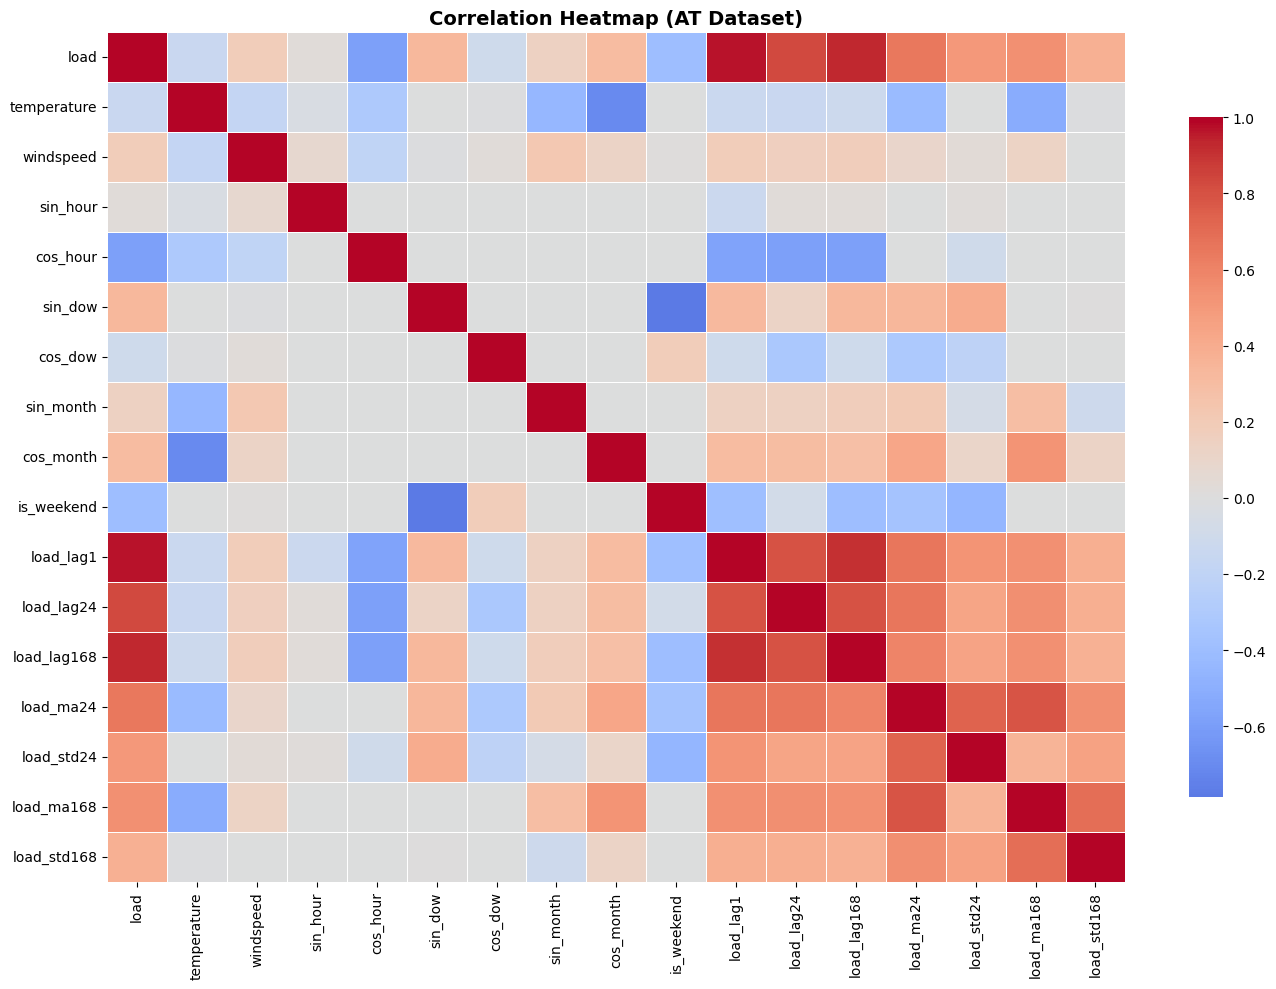

In [25]:

# ------------------------
# 5) HEATMAP ماتریس همبستگی
# ------------------------
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (AT Dataset)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

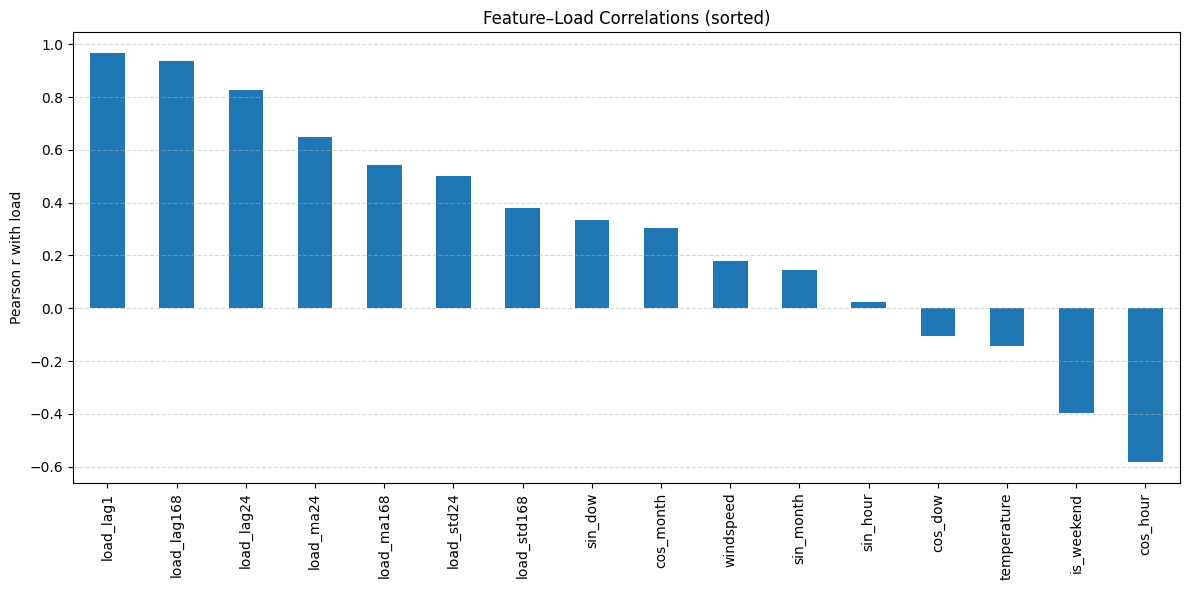

In [26]:
# ------------------------
# 6) نمودار همبستگی «فیچرها با load»
# ------------------------
corr_with_load = corr["load"].drop(labels=["load"]).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
corr_with_load.plot(kind='bar')
plt.ylabel("Pearson r with load")
plt.title("Feature–Load Correlations (sorted)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [15]:

# انتخاب متغیرهای نهایی + ذخیره خروجی آماده مدل
# ===========================

import os

# اگر می‌خواهی lag168 را هم داشته باشی، True کن (وقتی طول ورودی < 168 مفیدتر است)
use_lag168 = False   # یا True

# ستون‌های پایه مثل ورودی
base_cols = ["time", "load", "temperature", "windspeed"]

# فیچرهای چرخه‌ای + آخرهفته
cyclic_cols = ["sin_hour", "cos_hour", "sin_dow", "cos_dow", "sin_month", "cos_month", "is_weekend"]

# lagهای ضروری (بدون انباشتگی زیاد)
lag_cols = ["load_lag1", "load_lag24"]
if use_lag168:
    lag_cols.append("load_lag168")

# rolling‌های کم‌ریسک (نسخه‌های 24 ساعته؛ 168 را برای کاهش هم‌خطی حذف می‌کنیم)
roll_cols = ["load_ma24", "load_std24"]

# لیست نهایی
final_cols = base_cols + cyclic_cols + lag_cols + roll_cols

# اطمینان از وجود همه ستون‌ها
missing = [c for c in final_cols if c not in df_clean.columns]
if missing:
    raise ValueError(f"ستون‌های زیر هنوز ساخته نشده‌اند یا نام‌شان متفاوت است: {missing}")

# دیتافریم نهایی با ترتیب ستون‌ها
df_final = df_clean[final_cols].copy()

# نمایش خلاصه
print("✅ شکل نهایی:", df_final.shape)
print("ستون‌ها:", df_final.columns.tolist())

✅ شکل نهایی: (78744, 15)
ستون‌ها: ['time', 'load', 'temperature', 'windspeed', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'is_weekend', 'load_lag1', 'load_lag24', 'load_ma24', 'load_std24']


In [16]:
# ذخیره در اکسل و CSV (برای استفاده مستقیم در pipeline)
out_xlsx = "AT_features_final.xlsx"
out_csv  = "AT_features_final.csv"

with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
    df_final.to_excel(writer, sheet_name="features", index=False)

df_final.to_csv(out_csv, index=False, encoding="utf-8")

print("📁 فایل‌ها ذخیره شدند:")
print(" -", os.path.abspath(out_xlsx))
print(" -", os.path.abspath(out_csv))

📁 فایل‌ها ذخیره شدند:
 - /content/AT_features_final.xlsx
 - /content/AT_features_final.csv


In [17]:
import pandas as pd
save_dir = '/content/drive/MyDrive/Edit-Novel-Seq2Seq-Module-master/prepare_data/data'

# اگه پوشه وجود نداره، بسازش
import os
os.makedirs(save_dir, exist_ok=True)

# حالا مسیر فایل‌ها
out_xlsx = f"{save_dir}/AT_features_final.xlsx"
out_csv  = f"{save_dir}/AT_features_final.csv"

# ذخیره‌سازی
with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
    df_final.to_excel(writer, sheet_name="features", index=False)

df_final.to_csv(out_csv, index=False, encoding="utf-8")

print("📁 فایل‌ها در درایو ذخیره شدند:")
print(out_xlsx)
print(out_csv)

📁 فایل‌ها در درایو ذخیره شدند:
/content/drive/MyDrive/Edit-Novel-Seq2Seq-Module-master/prepare_data/data/AT_features_final.xlsx
/content/drive/MyDrive/Edit-Novel-Seq2Seq-Module-master/prepare_data/data/AT_features_final.csv
